# JA4 + JA4X Full Fingerprints (Random Forest)

## Data Loading and Initial Filtering

This section loads the combined fingerprint dataset, builds the JA4 + JA4X complete fingerprints experiment input, removes incomplete rows, and filters devices with enough samples for stratified evaluation.

In [1]:
import pandas as pd
from pathlib import Path

signature_columns = [
    "ja4",
    "ja4x"
]
selected_columns = ["device_name", *signature_columns]

csv_candidates = [
    Path("D:/TFG_GemmaVate/1_Data/raw_FINAL/raw_features.csv"),
    Path("/mnt/d/TFG_GemmaVate/1_Data/raw_FINAL/raw_features.csv"),
    Path("1_Data/raw_FINAL/raw_features.csv"),
]
csv_path = next((candidate for candidate in csv_candidates if candidate.exists()), csv_candidates[-1])

def is_valid_fingerprint(series: pd.Series) -> pd.Series:
    cleaned = series.fillna("").astype(str).str.strip().str.lower()
    return cleaned.ne("") & cleaned.ne("(empty)") & cleaned.ne("(emtpy)")

df = pd.read_csv(csv_path, dtype=str, low_memory=False)
df = df[
    is_valid_fingerprint(df["ja4"])
    & is_valid_fingerprint(df["ja4x"])
].copy()
df = df[selected_columns].copy()

print(f"Dataset used: {csv_path}")
print(f"Firmas completas analizadas: {signature_columns}")
print(f"Cantidad de filas after filtrar firmas vacias: {len(df)}")
df.head()

Dataset used: /mnt/d/TFG_GemmaVate/1_Data/raw_FINAL/raw_features.csv
Firmas completas analizadas: ['ja4', 'ja4x']
Cantidad de filas after filtrar firmas vacias: 323


,device_name,ja4,ja4x
394,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,f1bb6372_f1bb6372_000000000000
3043,Amazon_Alexa_Echo_Dot_1_Audio,t12i0407h2_dd22d19553a2_453ce47662e7,02ace205_02ace205_1c314e97029a
6039,Harman_Kardon_Audio,t12i0507h2_2af0c3a5c862_e0fb7d0a714d,02ace205_02ace205_1c314e97029a
6110,SmartThings_Hub,t13d311000_e8f1e7e78f70_5ac7197df9d2,0bc7f0af_0bc7f0af_000000000000
6466,Amazon_Alexa_Echo_Dot_2_Audio,t12i0407h2_dd22d19553a2_453ce47662e7,02ace205_02ace205_1c314e97029a


This section summarizes how many samples and distinct full-fingerprint bundles are available for each device.

Number of samples per device_name
device_name
Yi_Indoor_Camera                  85
Harman_Kardon_Audio               60
HeimVision_Smart_WiFi_Camera      38
SmartThings_Hub                   25
Amazon_Echo_Show_Audio            21
AeoTec_Smart_Home_Hub             19
Yi_Outdoor_Camera                 19
Rbcior_Camera                     16
Amazon_Alexa_Echo_Dot_2_Audio     12
Amazon_Alexa_Echo_Dot_1_Audio     11
UNKNOWN                            7
Arlo_Q_Indoor_Camera               4
Amazon_Alexa_Echo_Studio_Audio     2
Fibaro_Home_Center_Lite_Hub        2
TP_Link_Tapo_Camera                2

Number of distinct full-fingerprint bundles per device_name
device_name
UNKNOWN                           5
Amazon_Echo_Show_Audio            4
SmartThings_Hub                   3
Amazon_Alexa_Echo_Dot_1_Audio     2
Rbcior_Camera                     2
AeoTec_Smart_Home_Hub             2
Amazon_Alexa_Echo_Dot_2_Audio     1
Fibaro_Home_Center_Lite_Hub       1
Arlo_Q_Indoor_Camera              1
Am

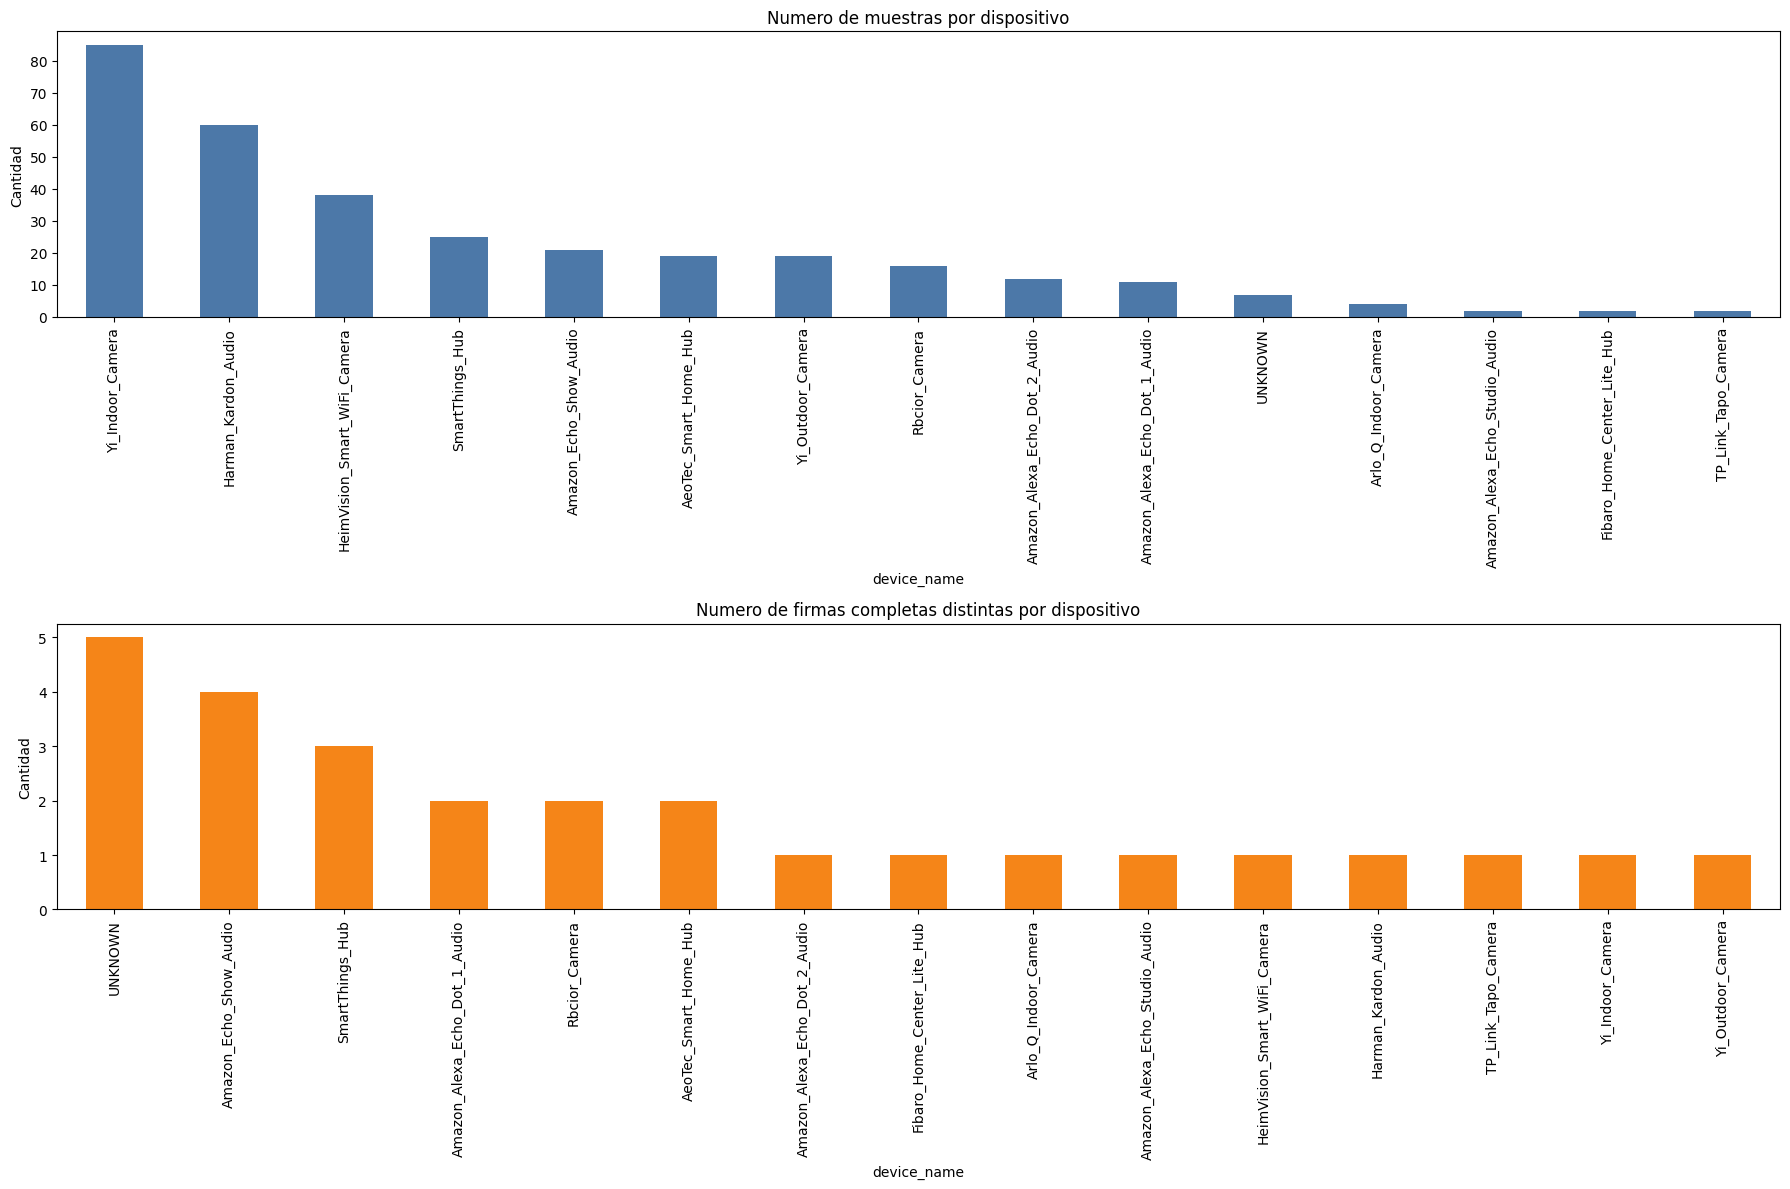

In [2]:
import matplotlib.pyplot as plt

df["signature_bundle"] = (
    df[signature_columns]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
)

total_samples = df.groupby("device_name").size().sort_values(ascending=False)
distinct_signatures = df.groupby("device_name")["signature_bundle"].nunique().sort_values(ascending=False)

print("Number of samples per device_name")
print(total_samples.to_string())
print()
print("Number of distinct full-fingerprint bundles per device_name")
print(distinct_signatures.to_string())

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

total_samples.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Numero de samples por device")
axes[0].set_xlabel("device_name")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=90)

distinct_signatures.plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Numero de firmas completas distintas por device")
axes[1].set_xlabel("device_name")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [3]:
min_samples_per_device = 3
max_samples_per_device = 60

device_counts = df["device_name"].value_counts()
valid_devices = device_counts[device_counts >= min_samples_per_device].index

df = df[df["device_name"].isin(valid_devices)].copy()

if max_samples_per_device is not None:
    df = (
        df.groupby("device_name", group_keys=False)
        .head(max_samples_per_device)
        .reset_index(drop=True)
    )
else:
    df = df.reset_index(drop=True)

filtered_counts = df["device_name"].value_counts().sort_values(ascending=False)

print("Number of records per device_name after filtering")
print(filtered_counts.to_string())
print()
print(f"Umbral minimo aplicado: {min_samples_per_device}")
print(f"Umbral maximum aplicado: {max_samples_per_device}")
print(f"Number of devices kept: {len(filtered_counts)}")
print(f"Total number of records after filtering: {len(df)}")

df.head()

Number of records per device_name after filtering
device_name
Harman_Kardon_Audio              60
Yi_Indoor_Camera                 60
HeimVision_Smart_WiFi_Camera     38
SmartThings_Hub                  25
Amazon_Echo_Show_Audio           21
AeoTec_Smart_Home_Hub            19
Yi_Outdoor_Camera                19
Rbcior_Camera                    16
Amazon_Alexa_Echo_Dot_2_Audio    12
Amazon_Alexa_Echo_Dot_1_Audio    11
UNKNOWN                           7
Arlo_Q_Indoor_Camera              4

Umbral minimo aplicado: 3
Umbral maximo aplicado: 60
Number of devices kept: 12
Total number of records after filtering: 292


,device_name,ja4,ja4x,signature_bundle
0,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,f1bb6372_f1bb6372_000000000000,t12d040600_39def8a70f78_9b994c9d23f8 | f1bb637...
1,Amazon_Alexa_Echo_Dot_1_Audio,t12i0407h2_dd22d19553a2_453ce47662e7,02ace205_02ace205_1c314e97029a,t12i0407h2_dd22d19553a2_453ce47662e7 | 02ace20...
2,Harman_Kardon_Audio,t12i0507h2_2af0c3a5c862_e0fb7d0a714d,02ace205_02ace205_1c314e97029a,t12i0507h2_2af0c3a5c862_e0fb7d0a714d | 02ace20...
3,SmartThings_Hub,t13d311000_e8f1e7e78f70_5ac7197df9d2,0bc7f0af_0bc7f0af_000000000000,t13d311000_e8f1e7e78f70_5ac7197df9d2 | 0bc7f0a...
4,Amazon_Alexa_Echo_Dot_2_Audio,t12i0407h2_dd22d19553a2_453ce47662e7,02ace205_02ace205_1c314e97029a,t12i0407h2_dd22d19553a2_453ce47662e7 | 02ace20...


## Full-Fingerprint Encoding

In this notebook, the model receives the full fingerprint as a categorical variable. There is no top-feature analysis because the unit of analysis is the complete fingerprint itself.

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

target_column = "device_name"
feature_columns = signature_columns

df_model = df[feature_columns + [target_column]].copy()

for column in feature_columns + [target_column]:
    df_model[column] = (
        df_model[column]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

class_counts_after_cleaning = df_model[target_column].value_counts()
valid_classes_for_split = class_counts_after_cleaning[class_counts_after_cleaning >= 3].index
removed_classes = sorted(set(class_counts_after_cleaning.index) - set(valid_classes_for_split))

if removed_classes:
    print(
        "Classes excluidas por no tener al menos 3 samples valid after la limpieza:",
        removed_classes,
    )
    df_model = df_model[df_model[target_column].isin(valid_classes_for_split)].reset_index(drop=True)

X = df_model[feature_columns].copy()
y = df_model[target_column].copy()

X_train_list, X_val_list, X_test_list = [], [], []
y_train_list, y_val_list, y_test_list = [], [], []

for device in df_model[target_column].unique():
    device_mask = df_model[target_column] == device
    X_device = X[device_mask].reset_index(drop=True)
    y_device = y[device_mask].reset_index(drop=True)

    X_temp, X_test_device, y_temp, y_test_device = train_test_split(
        X_device,
        y_device,
        test_size=0.2,
        random_state=42,
        shuffle=True,
    )

    train_ratio = 0.70 / 0.80
    X_train_device, X_val_device, y_train_device, y_val_device = train_test_split(
        X_temp,
        y_temp,
        train_size=train_ratio,
        random_state=42,
        shuffle=True,
    )

    X_train_list.append(X_train_device)
    X_val_list.append(X_val_device)
    X_test_list.append(X_test_device)
    y_train_list.append(y_train_device)
    y_val_list.append(y_val_device)
    y_test_list.append(y_test_device)

X_train_raw = pd.concat(X_train_list, ignore_index=True)
X_val_raw = pd.concat(X_val_list, ignore_index=True)
X_test_raw = pd.concat(X_test_list, ignore_index=True)
y_train_raw = pd.concat(y_train_list, ignore_index=True)
y_val_raw = pd.concat(y_val_list, ignore_index=True)
y_test_raw = pd.concat(y_test_list, ignore_index=True)

X_train = pd.get_dummies(
    X_train_raw,
    columns=feature_columns,
    dtype=np.int8,
    dummy_na=False,
    drop_first=False,
    prefix_sep="=",
)
X_val = pd.get_dummies(
    X_val_raw,
    columns=feature_columns,
    dtype=np.int8,
    dummy_na=False,
    drop_first=False,
    prefix_sep="=",
)
X_test = pd.get_dummies(
    X_test_raw,
    columns=feature_columns,
    dtype=np.int8,
    dummy_na=False,
    drop_first=False,
    prefix_sep="=",
)

union_columns = set(X_train.columns) | set(X_val.columns) | set(X_test.columns)
for col in union_columns:
    if col not in X_train.columns:
        X_train[col] = 0
    if col not in X_val.columns:
        X_val[col] = 0
    if col not in X_test.columns:
        X_test[col] = 0

X_train = X_train[sorted(union_columns)]
X_val = X_val[sorted(union_columns)]
X_test = X_test[sorted(union_columns)]

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_val = label_encoder.transform(y_val_raw)
y_test = label_encoder.transform(y_test_raw)
class_names = label_encoder.classes_

print("Split por device: 70% train, 10% val, 20% test")
print(f"Valid records after cleaning: {len(df_model)}")
print(f"Target classes: {len(class_names)}")
print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")
print(f"Number of columns after one-hot encoding de firmas completas: {X_train.shape[1]}")
print("First classes:", class_names[:10])

Split por device: 70% train, 10% val, 20% test
Valid records after cleaning: 292
Target classes: 12
Train size: 193
Validation size: 36
Test size: 63
Number of columns after one-hot encoding de firmas completas: 28
First classes: ['aeotec_smart_home_hub' 'amazon_alexa_echo_dot_1_audio'
 'amazon_alexa_echo_dot_2_audio' 'amazon_echo_show_audio'
 'arlo_q_indoor_camera' 'harman_kardon_audio'
 'heimvision_smart_wifi_camera' 'rbcior_camera' 'smartthings_hub'
 'unknown']


In [5]:
print("Class distribution in y_train_raw:")
print(y_train_raw.value_counts(normalize=True).sort_index())
print()

print("Class distribution in y_val_raw:")
print(y_val_raw.value_counts(normalize=True).sort_index())
print()

print("Class distribution in y_test_raw:")
print(y_test_raw.value_counts(normalize=True).sort_index())

Class distribution in y_train_raw:
device_name
aeotec_smart_home_hub            0.067358
amazon_alexa_echo_dot_1_audio    0.031088
amazon_alexa_echo_dot_2_audio    0.036269
amazon_echo_show_audio           0.067358
arlo_q_indoor_camera             0.010363
harman_kardon_audio              0.212435
heimvision_smart_wifi_camera     0.134715
rbcior_camera                    0.051813
smartthings_hub                  0.088083
unknown                          0.020725
yi_indoor_camera                 0.212435
yi_outdoor_camera                0.067358
Name: proportion, dtype: float64

Class distribution in y_val_raw:
device_name
aeotec_smart_home_hub            0.055556
amazon_alexa_echo_dot_1_audio    0.055556
amazon_alexa_echo_dot_2_audio    0.055556
amazon_echo_show_audio           0.083333
arlo_q_indoor_camera             0.027778
harman_kardon_audio              0.194444
heimvision_smart_wifi_camera     0.111111
rbcior_camera                    0.055556
smartthings_hub                  0

## Hyperparameter Search

This section runs the Random Forest model selection step and measures how long the search takes.

In [6]:
import time
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import ParameterGrid

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [20, 30, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"],
}

search_results = []
best_params = None
best_val_f1 = -1.0
best_val_accuracy = -1.0

print("Searching hyperparameters with the 10% validation split...")
print(f"Combinations to evaluate: {len(list(ParameterGrid(param_grid)))}")

search_start = time.time()
for params in ParameterGrid(param_grid):
    candidate = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1,
    )
    candidate.fit(X_train, y_train)

    train_pred = candidate.predict(X_train)
    val_pred = candidate.predict(X_val)

    train_f1 = f1_score(y_train, train_pred, average="macro", zero_division=0)
    val_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)
    val_accuracy = accuracy_score(y_val, val_pred)

    row = {
        **params,
        "train_macro_f1": float(train_f1),
        "val_macro_f1": float(val_f1),
        "val_accuracy": float(val_accuracy),
    }
    search_results.append(row)

    if (val_f1 > best_val_f1) or (val_f1 == best_val_f1 and val_accuracy > best_val_accuracy):
        best_val_f1 = val_f1
        best_val_accuracy = val_accuracy
        best_params = params

search_elapsed = time.time() - search_start
search_results_df = (
    pd.DataFrame(search_results)
    .sort_values(["val_macro_f1", "val_accuracy", "train_macro_f1"], ascending=False)
    .reset_index(drop=True)
)

print(f"Busqueda completada en {search_elapsed:.1f} s")
print()
print("Top 10 configurations by validation macro F1:")
display(search_results_df.head(10))
print()
print("Best hyperparameters found:")
print(best_params)
print(f"Best macro F1 on validation: {best_val_f1:.4f}")
print(f"Associated validation accuracy: {best_val_accuracy:.4f}")

Searching hyperparameters con el 10% de validation...
Combinations a evaluar: 24
Busqueda completada en 15.6 s

Top 10 configurations por macro F1 en validation:


,class_weight,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,train_macro_f1,val_macro_f1,val_accuracy
0,balanced,20.0,sqrt,1,2,100,0.659226,0.616811,0.666667
1,balanced,30.0,sqrt,1,2,100,0.659226,0.616811,0.666667
2,balanced,NaN,sqrt,1,2,100,0.659226,0.616811,0.666667
3,balanced,20.0,sqrt,1,2,200,0.659226,0.604906,0.666667
4,balanced,30.0,sqrt,1,2,200,0.659226,0.604906,0.666667
5,balanced,NaN,sqrt,1,2,200,0.659226,0.604906,0.666667
6,balanced,20.0,sqrt,1,10,100,0.647855,0.604906,0.666667
7,balanced,20.0,sqrt,1,10,200,0.647855,0.604906,0.666667
8,balanced,30.0,sqrt,1,10,100,0.647855,0.604906,0.666667
9,balanced,30.0,sqrt,1,10,200,0.647855,0.604906,0.666667



Best hyperparameters found:
{'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best macro F1 en validation: 0.6168
Accuracy asociada en validation: 0.6667


## Final Model Training

This section retrains the selected model with the combined train and validation data before evaluating it on the held-out test split.

In [7]:
from sklearn.metrics import classification_report, precision_score, recall_score, top_k_accuracy_score

X_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_train_val = np.concatenate([y_train, y_val])

rf_final_model = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1,
)
rf_final_model.fit(X_train_val, y_train_val)

train_val_predictions = rf_final_model.predict(X_train_val)
test_predictions = rf_final_model.predict(X_test)
test_probabilities = rf_final_model.predict_proba(X_test)

train_val_accuracy = accuracy_score(y_train_val, train_val_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

train_val_f1_macro = f1_score(y_train_val, train_val_predictions, average="macro", zero_division=0)
test_f1_macro = f1_score(y_test, test_predictions, average="macro", zero_division=0)

macro_precision = precision_score(y_test, test_predictions, average="macro", zero_division=0)
macro_recall = recall_score(y_test, test_predictions, average="macro", zero_division=0)

top_3_k = min(3, len(class_names))
top_5_k = min(5, len(class_names))

if len(class_names) <= top_3_k:
    test_top_3_accuracy = 1.0
else:
    test_top_3_accuracy = top_k_accuracy_score(
        y_test,
        test_probabilities,
        k=top_3_k,
        labels=np.arange(len(class_names)),
    )

if len(class_names) <= top_5_k:
    test_top_5_accuracy = 1.0
else:
    test_top_5_accuracy = top_k_accuracy_score(
        y_test,
        test_probabilities,
        k=top_5_k,
        labels=np.arange(len(class_names)),
    )

prediction_times = []
for sample_index in range(len(X_test)):
    sample_features = X_test.iloc[[sample_index]]
    start_time = time.perf_counter()
    rf_final_model.predict_proba(sample_features)
    elapsed_time = time.perf_counter() - start_time
    prediction_times.append(elapsed_time)

average_prediction_time = float(np.mean(prediction_times))

print("=" * 80)
print("GENERAL RESULTS")
print("=" * 80)
print(f"Final model retrained with train+validation: {len(X_train_val)} samples")
print()
print("Accuracy:")
print(f"  - Train+Val: {train_val_accuracy:.4f}")
print(f"  - Test:      {test_accuracy:.4f}")
print()
print("Macro F1 Score:")
print(f"  - Best validation: {best_val_f1:.4f}")
print(f"  - Train+Val:        {train_val_f1_macro:.4f}")
print(f"  - Test:             {test_f1_macro:.4f}")
print()
print("Top-k accuracy on the test split:")
print(f"  - top_{top_3_k}_accuracy: {test_top_3_accuracy:.4f}")
print(f"  - top_{top_5_k}_accuracy: {test_top_5_accuracy:.4f}")
print()
print(f"Average prediction time: {average_prediction_time:.6f} s ({average_prediction_time * 1000:.3f} ms)")
print()
print("=" * 80)
print("CLASSIFICATION REPORT - TEST")
print("=" * 80)
print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0,
    )
)

GENERAL RESULTS
Final model retrained with train+validation: 229 samples

Accuracy:
  - Train+Val: 0.6769
  - Test:      0.6349

Macro F1 Score:
  - Best validation: 0.6168
  - Train+Val:        0.6735
  - Test:             0.5456

Top-k accuracy on the test split:
  - top_3_accuracy: 0.9683
  - top_5_accuracy: 0.9841

Average prediction time: 0.052080 s (52.080 ms)

CLASSIFICATION REPORT - TEST
                               precision    recall  f1-score   support

        aeotec_smart_home_hub       0.38      0.75      0.50         4
amazon_alexa_echo_dot_1_audio       0.00      0.00      0.00         3
amazon_alexa_echo_dot_2_audio       0.50      1.00      0.67         3
       amazon_echo_show_audio       1.00      1.00      1.00         5
         arlo_q_indoor_camera       1.00      1.00      1.00         1
          harman_kardon_audio       1.00      1.00      1.00        12
 heimvision_smart_wifi_camera       1.00      1.00      1.00         8
                rbcior_camera   

## Final Evaluation and Metrics Summary

This section summarizes accuracy, macro metrics, top-k accuracy, prediction time, and the confusion matrix for the final Random Forest model.

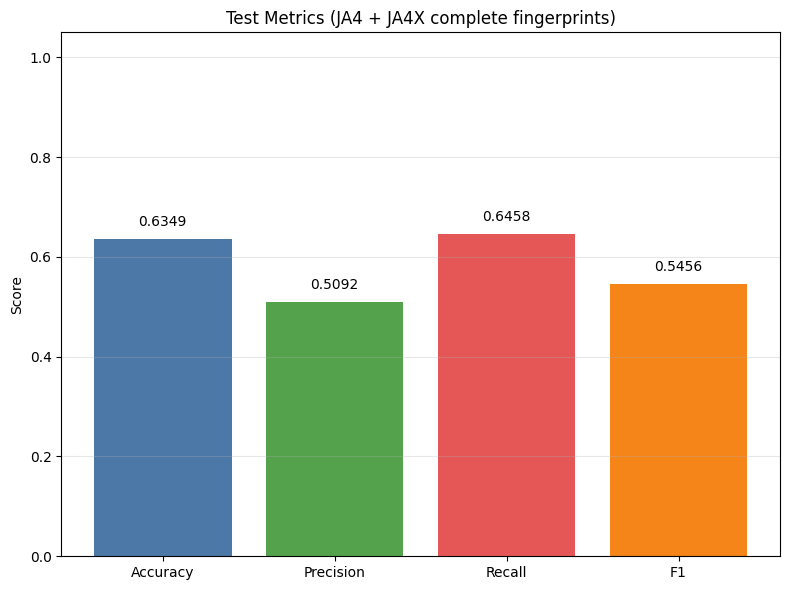

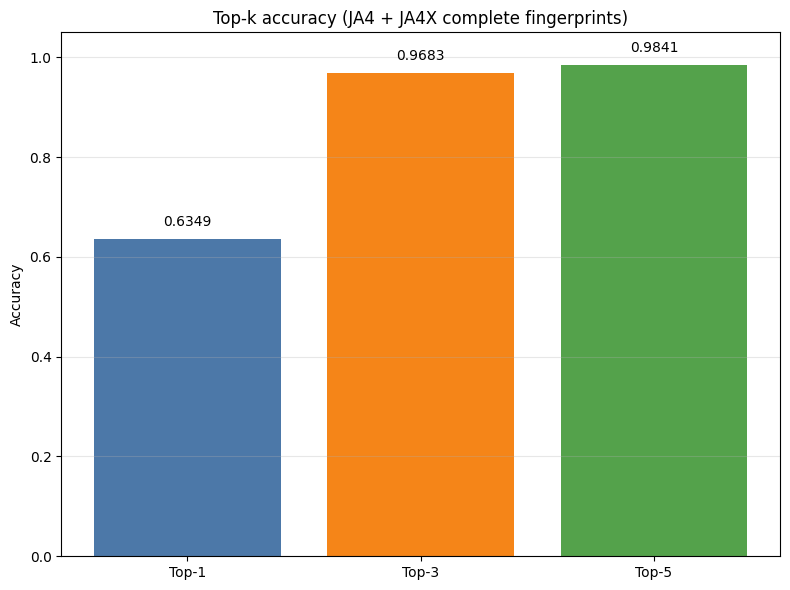

FINAL METRICS SUMMARY
- validation_macro_f1_for_tuning: 0.6168
- test_accuracy: 0.6349
- test_macro_precision: 0.5092
- test_macro_recall: 0.6458
- test_macro_f1: 0.5456
- top_3_accuracy: 0.9683
- top_5_accuracy: 0.9841
- avg_prediction_time_ms: 52.0795

Bestes parameters useds en el model final:
  - class_weight: balanced
  - max_depth: 20
  - max_features: sqrt
  - min_samples_leaf: 1
  - min_samples_split: 2
  - n_estimators: 100


In [8]:
import matplotlib.pyplot as plt

feature_set_label = "JA4 + JA4X complete fingerprints"

metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [test_accuracy, macro_precision, macro_recall, test_f1_macro]

top_k_labels = ["Top-1", "Top-3", "Top-5"]
top_k_values = [test_accuracy, test_top_3_accuracy, test_top_5_accuracy]

plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, values, color=["#4C78A8", "#54A24B", "#E45756", "#F58518"])
plt.title(f"Test Metrics ({feature_set_label})")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
bars = plt.bar(top_k_labels, top_k_values, color=["#4C78A8", "#F58518", "#54A24B"])
plt.title(f"Top-k accuracy ({feature_set_label})")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

metrics_summary = {
    "validation_macro_f1_for_tuning": float(best_val_f1),
    "test_accuracy": float(test_accuracy),
    "test_macro_precision": float(macro_precision),
    "test_macro_recall": float(macro_recall),
    "test_macro_f1": float(test_f1_macro),
    f"top_{top_3_k}_accuracy": float(test_top_3_accuracy),
    f"top_{top_5_k}_accuracy": float(test_top_5_accuracy),
    "avg_prediction_time_ms": float(average_prediction_time * 1000),
}

print("=" * 80)
print("FINAL METRICS SUMMARY")
print("=" * 80)
for metric_name, metric_value in metrics_summary.items():
    print(f"- {metric_name}: {metric_value:.4f}")

print()
print("Best parameters used in the final model:")
for param, value in best_params.items():
    print(f"  - {param}: {value}")

## Save the Trained Model

This section stores the final Random Forest model and its metadata under 3_Results/models so the experiment can be reused later.

In [ ]:
import joblib
import json
from pathlib import Path

project_root = Path(r"D:\TFG_GemmaBeatrizVate")
if not project_root.exists():
    project_root = Path("/mnt/d/TFG_GemmaBeatrizVate")

model_dir = project_root / "3_Results" / "models" / "rf_ja4_ja4x_full_fingerprint"
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "model.joblib"
joblib.dump(rf_final_model, model_path)

artifacts = {
    "experiment": "rf_ja4_ja4x_full_fingerprint",
    "signature_columns": signature_columns,
    "class_names": class_names.tolist(),
    "best_params": best_params,
    "metrics_summary": metrics_summary,
    "train_size": int(len(X_train)),
    "validation_size": int(len(X_val)),
    "test_size": int(len(X_test)),
    "train_validation_size": int(len(X_train_val)),
    "min_samples_per_device": int(min_samples_per_device),
    "max_samples_per_device": None if max_samples_per_device is None else int(max_samples_per_device),
}

artifacts_path = model_dir / "artifacts.json"
with artifacts_path.open("w", encoding="utf-8") as file:
    json.dump(artifacts, file, indent=2)

print(f"Model saved to: {model_path}")
print(f"Artifacts saved to: {artifacts_path}")